# Step 2: label the segment manually
run 

python main.py labeler (see utils main.py)

# Step 3: Run this notebook to train MobileNetV2 to classify the cropped images

# Crochet Symbol Classifier — MobileNetV2 Transfer Learning

HOG features cannot reliably describe crochet symbols because:
* Symbols differ **structurally** (fan vs cross vs oval), not just in local gradients
* The dataset is tiny (< 200 real images) — HOG+SVM overfits quickly
* Symbols appear at **varying orientations** that HOG handles poorly

**This notebook uses a pretrained MobileNetV2 as a frozen feature extractor.**  
Only a small classification head is trained, so the model generalises well even with
very few samples per class.

Pipeline:
```
Grayscale crop → 3-ch resize (224×224) → MobileNetV2 backbone (frozen)
    → 1280-d feature vector → Dropout → Linear(256) → ReLU → Linear(n_classes)
```


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import MobileNet_V2_Weights

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

DEVICE   = "mps"
IMG_SIZE = 224          # MobileNetV2 input size
DATA_DIR = Path('data/segments/labeled')

print(f'Device: {DEVICE}')
print(f'PyTorch {torch.__version__}')


Device: mps
PyTorch 2.11.0


In [74]:
# ── Transforms ────────────────────────────────────────────────────────────
# For grayscale line-art we use geometric + photometric augmentations
# that simulate real-photo variation without altering symbol identity.

TRAIN_TF = transforms.Compose([
    transforms.RandomRotation(degrees=20, fill=255),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08),
                             scale=(0.85, 1.15), fill=255),
    transforms.ColorJitter(brightness=0.35, contrast=0.35),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    # MobileNetV2 ImageNet stats — still useful even for grayscale→RGB
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])

VAL_TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])


class StitchDataset(Dataset):
    """
    Loads grayscale stitch crops from a folder-per-class structure.
    Converts each to 3-channel RGB (repeating the grey channel) so that
    MobileNetV2's pretrained filters can be applied directly.
    """
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)   # (H,W,3)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ── Load file paths + labels ───────────────────────────────────────────────
all_paths, all_labels = [], []
class_counts = {}

for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    files = list(class_dir.glob('*.png'))
    class_counts[class_dir.name] = len(files)
    if not files:
        print(f'  ⚠ Skipping {class_dir.name!r} — no images')
        continue
    all_paths  += files
    all_labels += [class_dir.name] * len(files)

le = LabelEncoder().fit(all_labels)
y  = le.transform(all_labels)

print('Class distribution:')
for cls, n in class_counts.items():
    print(f'  {cls}: {n}')
print(f'\nTotal: {len(all_paths)} images | {len(le.classes_)} classes')
print(f'Classes: {list(le.classes_)}')


Class distribution:
  chain: 761
  double: 410
  ensemble_chain: 79
  ensemble_wrong: 85
  fan: 38
  half_double: 36
  noise: 48
  single: 100
  treble: 23

Total: 1580 images | 9 classes
Classes: [np.str_('chain'), np.str_('double'), np.str_('ensemble_chain'), np.str_('ensemble_wrong'), np.str_('fan'), np.str_('half_double'), np.str_('noise'), np.str_('single'), np.str_('treble')]


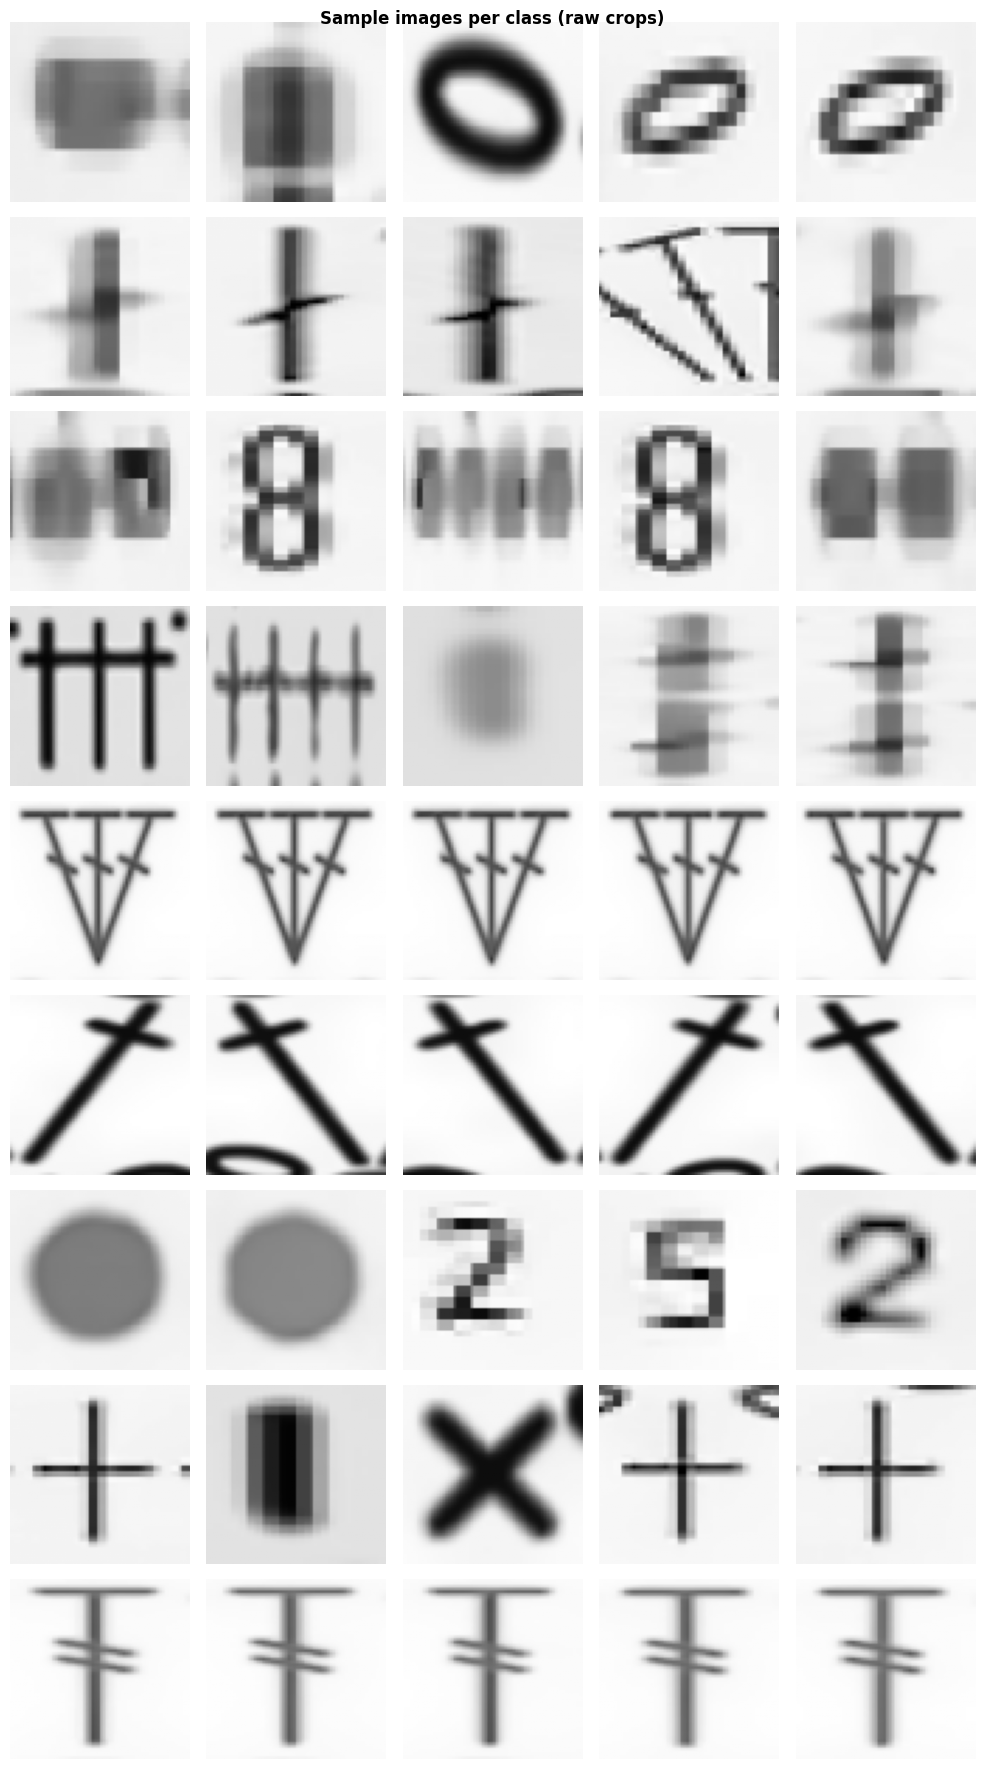

In [75]:
# Visualise a few samples per class (raw, before any transform)
classes = list(le.classes_)
n_show  = 5
fig, axes = plt.subplots(len(classes), n_show, figsize=(n_show*2, len(classes)*2))

for ri, cls in enumerate(classes):
    idxs = [i for i, lbl in enumerate(all_labels) if lbl == cls][:n_show]
    for ci in range(n_show):
        ax = axes[ri, ci]
        ax.axis('off')
        if ci < len(idxs):
            img = cv2.imread(str(all_paths[idxs[ci]]), cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        if ci == 0:
            ax.set_ylabel(cls, fontsize=10, rotation=0, labelpad=50, va='center')

plt.suptitle('Sample images per class (raw crops)', fontweight='bold')
plt.tight_layout()
plt.show()


In [76]:
# Stratified 80 / 20 split
idx_train, idx_test = train_test_split(
    range(len(all_paths)), test_size=0.20,
    random_state=42, stratify=y
)

train_paths  = [all_paths[i]  for i in idx_train]
train_labels = [y[i]          for i in idx_train]
test_paths   = [all_paths[i]  for i in idx_test]
test_labels  = [y[i]          for i in idx_test]

print(f'Train: {len(train_paths)} | Test: {len(test_paths)}')
print('Train distribution:', Counter(le.inverse_transform(train_labels)))

# WeightedRandomSampler — upsamples minority classes so every batch
# sees a roughly balanced class mix despite the skewed dataset.
class_counts_arr = np.bincount(train_labels)
weights = 1.0 / class_counts_arr[train_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(train_labels),
                                 replacement=True)

train_ds = StitchDataset(train_paths, train_labels, TRAIN_TF)
test_ds  = StitchDataset(test_paths,  test_labels,  VAL_TF)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f'\nBatches per epoch: {len(train_loader)}')


Train: 1264 | Test: 316
Train distribution: Counter({np.str_('chain'): 609, np.str_('double'): 328, np.str_('single'): 80, np.str_('ensemble_wrong'): 68, np.str_('ensemble_chain'): 63, np.str_('noise'): 38, np.str_('fan'): 31, np.str_('half_double'): 29, np.str_('treble'): 18})

Batches per epoch: 79


In [77]:
class StitchMobileNet(nn.Module):
    """
    MobileNetV2 backbone (ImageNet pretrained, frozen) + lightweight head.

    Why freeze the backbone?
    * Dataset has < 200 real images → fine-tuning all layers would overfit.
    * MobileNetV2's low-level filters (edges, curves) already describe
      line-art symbols perfectly without any adaptation.
    * Only the head (2 FC layers) is trained from scratch.

    Architecture of the head:
        1280-d pool → Dropout(0.4) → Linear(256) → GELU → Linear(n_classes)
    """
    def __init__(self, n_classes: int, dropout: float = 0.40):
        super().__init__()
        backbone = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

        # Freeze every backbone parameter
        for p in backbone.parameters():
            p.requires_grad = False

        self.features   = backbone.features          # output: (B, 1280, 7, 7)
        self.pool       = nn.AdaptiveAvgPool2d(1)    # → (B, 1280, 1, 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, 256),
            nn.GELU(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)


n_classes = len(le.classes_)
model     = StitchMobileNet(n_classes).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,}  /  Total: {total:,}')
print(f'Classes ({n_classes}): {list(le.classes_)}')


Trainable params: 330,249  /  Total: 2,554,121
Classes (9): [np.str_('chain'), np.str_('double'), np.str_('ensemble_chain'), np.str_('ensemble_wrong'), np.str_('fan'), np.str_('half_double'), np.str_('noise'), np.str_('single'), np.str_('treble')]


Training on mps for 60 epochs…


  2%|▏         | 1/60 [00:08<08:06,  8.25s/it]

  Epoch   1 | train loss 1.647 acc 0.465 | val loss 1.215 acc 0.718


 17%|█▋        | 10/60 [01:23<06:55,  8.30s/it]

  Epoch  10 | train loss 0.907 acc 0.805 | val loss 0.967 acc 0.788


...

  Epoch  40 | train loss 0.769 acc 0.864 | val loss 0.755 acc 0.889


 83%|████████▎ | 50/60 [06:35<01:12,  7.28s/it]

  Epoch  50 | train loss 0.757 acc 0.859 | val loss 0.762 acc 0.873


100%|██████████| 60/60 [07:45<00:00,  7.77s/it]

  Epoch  60 | train loss 0.733 acc 0.883 | val loss 0.732 acc 0.896
Done.


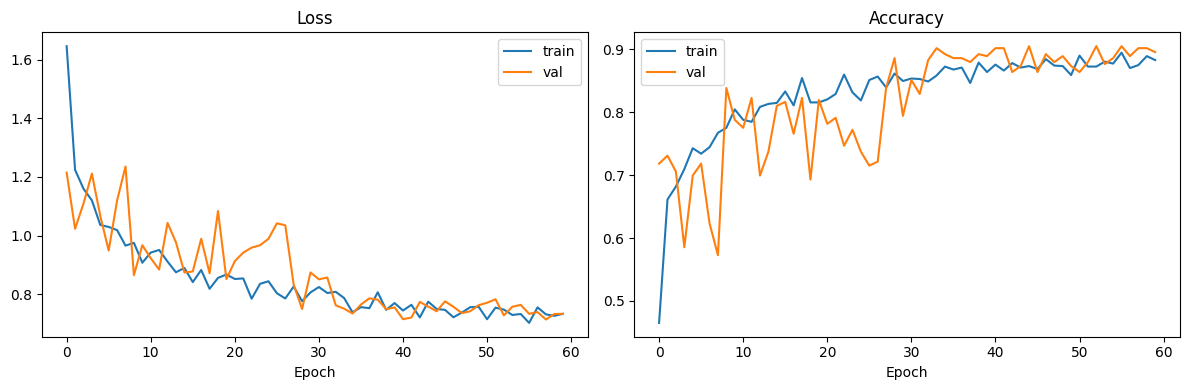

In [78]:
N_EPOCHS   = 60
LR         = 3e-3
WD         = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WD
)
# Cosine annealing: smoothly reduces LR to near-zero by the last epoch
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)
    return total_loss / n, correct / n


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Training on {DEVICE} for {N_EPOCHS} epochs…')
for epoch in tqdm(range(1, N_EPOCHS + 1)):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(test_loader,  training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d} | '
              f'train loss {tr_loss:.3f} acc {tr_acc:.3f} | '
              f'val loss {va_loss:.3f} acc {va_acc:.3f}')

print('Done.')

# Learning-curve plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='train'); ax2.plot(history['val_acc'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()


MobileNetV2 — Classification Report
                precision    recall  f1-score   support

         chain       0.99      0.92      0.95       152
        double       0.95      0.87      0.90        82
ensemble_chain       0.75      0.75      0.75        16
ensemble_wrong       0.75      0.88      0.81        17
           fan       1.00      0.86      0.92         7
   half_double       0.41      1.00      0.58         7
         noise       0.56      0.90      0.69        10
        single       1.00      0.90      0.95        20
        treble       0.83      1.00      0.91         5

      accuracy                           0.90       316
     macro avg       0.80      0.90      0.83       316
  weighted avg       0.92      0.90      0.90       316



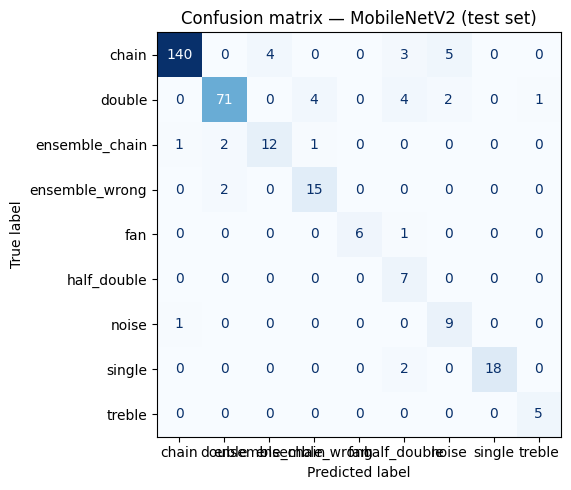

In [79]:
# ── Collect predictions on the test set ──────────────────────────────────
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

print('MobileNetV2 — Classification Report')
print(classification_report(all_true, all_preds,
                              target_names=le.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    all_true, all_preds, display_labels=le.classes_,
    ax=ax, colorbar=False, cmap='Blues'
)
plt.title('Confusion matrix — MobileNetV2 (test set)')
plt.tight_layout()
plt.show()


33 misclassified sample(s):


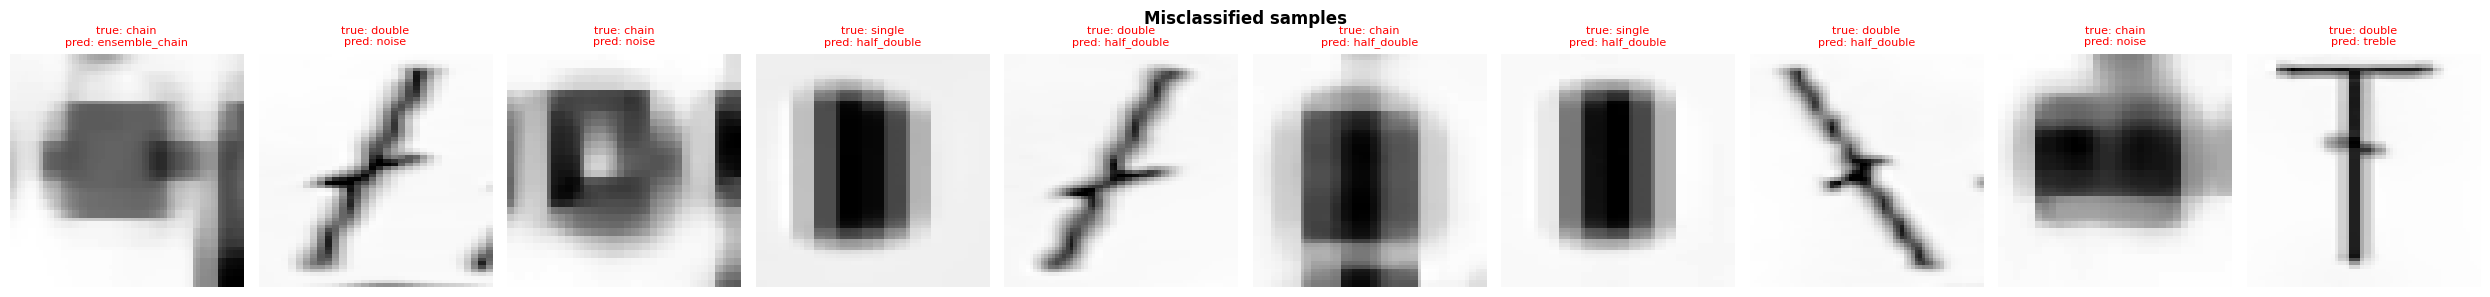

In [80]:
# Show misclassified samples to understand failure modes
wrong_idx = np.where(all_preds != all_true)[0]
if len(wrong_idx) == 0:
    print('No misclassifications on the test set!')
else:
    print(f'{len(wrong_idx)} misclassified sample(s):')
    n_show = min(len(wrong_idx), 10)
    fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, wrong_idx[:n_show]):
        img = cv2.imread(str(test_paths[idx]), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.set_title(
            f'true: {le.classes_[all_true[idx]]}\npred: {le.classes_[all_preds[idx]]}',
            fontsize=8, color='red'
        )
        ax.axis('off')
    plt.suptitle('Misclassified samples', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [81]:
# Save the full model + label encoder so run_pipeline can load it
torch.save({
    'model_state': model.state_dict(),
    'n_classes':   n_classes,
    'classes':     list(le.classes_),
}, 'mobilenet_model.pt')

joblib.dump({'label_encoder': le}, 'mobilenet_le.joblib')

print('Model  → mobilenet_model.pt')
print('Labels → mobilenet_le.joblib')
print()
print('To load and predict on a new crop:')
print("""
  checkpoint = torch.load('mobilenet_model.pt', map_location='cpu', weights_only=False)
  model = StitchMobileNet(checkpoint['n_classes'])
  model.load_state_dict(checkpoint['model_state'])
  model.eval()
""")


Model  → mobilenet_model.pt
Labels → mobilenet_le.joblib

To load and predict on a new crop:

  checkpoint = torch.load('mobilenet_model.pt', map_location='cpu', weights_only=False)
  model = StitchMobileNet(checkpoint['n_classes'])
  model.load_state_dict(checkpoint['model_state'])
  model.eval()

